# Toxicity & Sentiment Analysis


In [8]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load Dataset

In [5]:
edges_df = pd.read_csv("../data/processed/graph_edges.csv")

edges_df.head()

,source,target,sentiment
0,leagueoflegends,teamredditteams,1
1,theredlion,soccer,-1
2,inlandempire,bikela,1
3,nfl,cfb,1
4,playmygame,gamedev,1


# Clean Data

In [6]:
edges_df = edges_df.dropna()

edges_df = edges_df[
    (edges_df["source"].str.strip() != "") &
    (edges_df["target"].str.strip() != "")
]

# Create Directed Graph

In [9]:
G = nx.from_pandas_edgelist(
    edges_df,
    source="source",
    target="target",
    create_using=nx.DiGraph()
)

# Create Toxicity Labels

In [10]:
edges_df["is_toxic"] = edges_df["sentiment"].apply(
    lambda x: 1 if x == -1 else 0
)

# Compute Subreddit Toxicity Metrics

In [11]:
source_stats = edges_df.groupby("source").agg(
    total_outgoing=("sentiment", "count"),
    toxic_outgoing=("is_toxic", "sum")
)

target_stats = edges_df.groupby("target").agg(
    total_incoming=("sentiment", "count"),
    toxic_incoming=("is_toxic", "sum")
)

toxicity_df = source_stats.join(target_stats, how="outer").fillna(0)

toxicity_df["toxicity_ratio"] = (
    toxicity_df["toxic_outgoing"] /
    toxicity_df["total_outgoing"]
)

toxicity_df = toxicity_df.fillna(0)

toxicity_df.head()

,total_outgoing,toxic_outgoing,total_incoming,toxic_incoming,toxicity_ratio
01001111010100000,0.0,0.0,1.0,0.0,0.0
0131,0.0,0.0,1.0,0.0,0.0
07scape,2.0,0.0,3.0,0.0,0.0
0b0t,0.0,0.0,1.0,0.0,0.0
0bservat0ry,0.0,0.0,2.0,0.0,0.0


# Create Toxicity Score

In [12]:
toxicity_df["toxicity_score"] = (
    toxicity_df["toxicity_ratio"] * 0.6 +
    (toxicity_df["toxic_incoming"] /
     (toxicity_df["total_incoming"] + 1)) * 0.4
)

In [13]:
scaler = MinMaxScaler()

toxicity_df["normalized_toxicity"] = scaler.fit_transform(
    toxicity_df[["toxicity_score"]]
)

# Load Centrality Results

In [14]:
centrality_df = pd.read_csv(
    "../notebooks/results/centrality_results.csv"
)

centrality_df.head()

,Subreddit Node,In-Degree Centrality,Out-Degree Centrality,Total Degree Centrality,Betweenness Centrality,Closeness Centrality
0,askreddit,0.060404,0.010146,0.070550,0.052596,0.313949
1,subredditdrama,0.012690,0.037735,0.050425,0.049401,0.262502
2,iama,0.046008,0.010733,0.056742,0.044142,0.304570
3,outoftheloop,0.016547,0.014172,0.030719,0.028853,0.272173
4,writingprompts,0.020041,0.011907,0.031949,0.017028,0.256204


# Merge Toxicity + Centrality

In [18]:
final_df = toxicity_df.merge(
    centrality_df,
    left_index=True,
    right_on="Subreddit Node",
    how="left"
)
final_df.head()

,total_outgoing,toxic_outgoing,total_incoming,toxic_incoming,toxicity_ratio,toxicity_score,normalized_toxicity,Subreddit Node,In-Degree Centrality,Out-Degree Centrality,Total Degree Centrality,Betweenness Centrality,Closeness Centrality
11886,0.0,0.0,1.0,0.0,0.0,0.0,0.0,01001111010100000,0.000028,0.000000,0.000028,0.0,0.126617
27252,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0131,0.000028,0.000000,0.000028,0.0,0.168672
13152,2.0,0.0,3.0,0.0,0.0,0.0,0.0,07scape,0.000028,0.000028,0.000056,0.0,0.166976
34834,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0b0t,0.000028,0.000000,0.000028,0.0,0.000028
16765,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0bservat0ry,0.000056,0.000000,0.000056,0.0,0.194720


# Correlation Analysis

In [19]:
correlation = final_df[
    [
        "normalized_toxicity",
        "Total Degree Centrality",
        "Betweenness Centrality",
        "Closeness Centrality"
    ]
].corr()

print(correlation)

                         normalized_toxicity  Total Degree Centrality  \
normalized_toxicity                 1.000000                 0.074441   
Total Degree Centrality             0.074441                 1.000000   
Betweenness Centrality              0.031770                 0.831577   
Closeness Centrality                0.052590                 0.236861   

                         Betweenness Centrality  Closeness Centrality  
normalized_toxicity                    0.031770              0.052590  
Total Degree Centrality                0.831577              0.236861  
Betweenness Centrality                 1.000000              0.106015  
Closeness Centrality                   0.106015              1.000000  


# Most Toxic Communities

In [20]:
top_toxic = final_df.sort_values(
    by="normalized_toxicity",
    ascending=False
).head(20)

top_toxic

,total_outgoing,toxic_outgoing,total_incoming,toxic_incoming,toxicity_ratio,toxicity_score,normalized_toxicity,Subreddit Node,In-Degree Centrality,Out-Degree Centrality,Total Degree Centrality,Betweenness Centrality,Closeness Centrality
33369,1.0,1.0,5.0,4.0,1.0,0.866667,1.000000,tomorrow,0.000028,0.000028,0.000056,0.000000e+00,0.172739
32382,1.0,1.0,2.0,2.0,1.0,0.866667,1.000000,macsucks,0.000056,0.000028,0.000084,0.000000e+00,0.162592
9542,2.0,2.0,1.0,1.0,1.0,0.800000,0.923077,otheroffmychest,0.000028,0.000056,0.000084,1.266545e-08,0.000028
27928,1.0,1.0,3.0,2.0,1.0,0.800000,0.923077,enoughpaulspam,0.000056,0.000028,0.000084,0.000000e+00,0.159536
21357,1.0,1.0,1.0,1.0,1.0,0.800000,0.923077,rice,0.000028,0.000028,0.000056,0.000000e+00,0.163314
6750,1.0,1.0,1.0,1.0,1.0,0.800000,0.923077,rcsupplies,0.000028,0.000028,0.000056,1.624018e-06,0.000028
4286,1.0,1.0,1.0,1.0,1.0,0.800000,0.923077,nofakereddit,0.000028,0.000028,0.000056,2.029633e-05,0.136905
9460,1.0,1.0,1.0,1.0,1.0,0.800000,0.923077,puahate,0.000028,0.000028,0.000056,1.710641e-08,0.156254
7701,1.0,1.0,1.0,1.0,1.0,0.800000,0.923077,criminology,0.000028,0.000028,0.000056,3.927807e-07,0.141369
9857,3.0,3.0,1.0,1.0,1.0,0.800000,0.923077,topcuntsofreddit,0.000028,0.000084,0.000112,2.809635e-09,0.133492


# Most Negative Connections

In [21]:
negative_edges = edges_df[
    edges_df["sentiment"] == -1
]

negative_edges.head()

,source,target,sentiment,is_toxic
1,theredlion,soccer,-1,1
34,karmaconspiracy,funny,-1,1
43,badkarma,gamesell,-1,1
53,casualiama,teenagers,-1,1
55,australia,sydney,-1,1


# Toxicity Hubs

In [22]:
toxicity_hubs = final_df[
    (final_df["normalized_toxicity"] > 0.5) &
    (
        final_df["Total Degree Centrality"]
        >
        final_df["Total Degree Centrality"].mean()
    )
]
toxicity_hubs.head()

,total_outgoing,toxic_outgoing,total_incoming,toxic_incoming,toxicity_ratio,toxicity_score,normalized_toxicity,Subreddit Node,In-Degree Centrality,Out-Degree Centrality,Total Degree Centrality,Betweenness Centrality,Closeness Centrality
22959,8.0,8.0,0.0,0.0,1.0,0.600000,0.692308,christianlaughs,0.000000,0.000224,0.000224,0.000000e+00,0.000000
1822,1.0,1.0,127.0,25.0,1.0,0.678125,0.782452,cringe,0.002264,0.000028,0.002292,7.686664e-05,0.234729
6541,5.0,4.0,10.0,0.0,0.8,0.480000,0.553846,evilbuildings,0.000280,0.000140,0.000419,2.225689e-06,0.204036
8005,1.0,1.0,31.0,5.0,1.0,0.662500,0.764423,fellowkids,0.000587,0.000028,0.000615,2.590358e-07,0.206740
3800,7.0,7.0,1.0,0.0,1.0,0.600000,0.692308,fuckredditmods,0.000028,0.000196,0.000224,2.169928e-05,0.160276


# Visualization — Toxicity Distribution

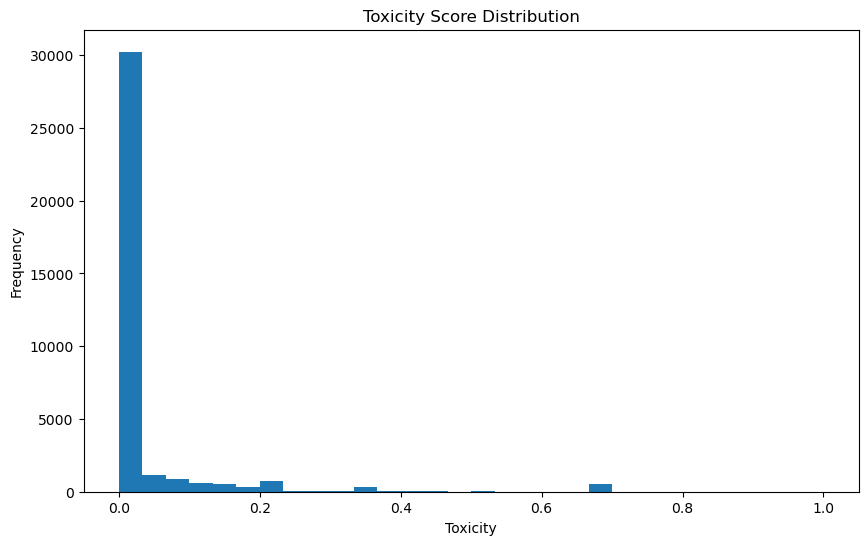

In [23]:
plt.figure(figsize=(10,6))

plt.hist(
    final_df["normalized_toxicity"],
    bins=30
)

plt.title("Toxicity Score Distribution")
plt.xlabel("Toxicity")
plt.ylabel("Frequency")

plt.show()

# Visualization — Top Toxic Communities

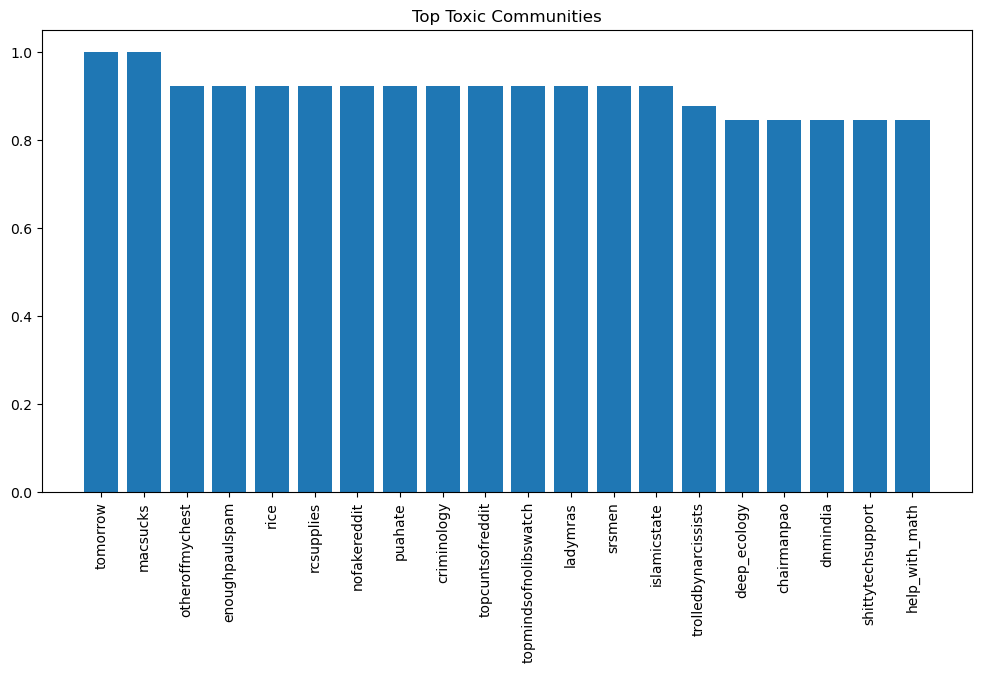

In [28]:
plt.figure(figsize=(12,6))

plt.bar(
    top_toxic["Subreddit Node"],
    top_toxic["normalized_toxicity"]
)

plt.xticks(rotation=90)

plt.title("Top Toxic Communities")

plt.show()

# Visualization — Toxicity vs Centrality

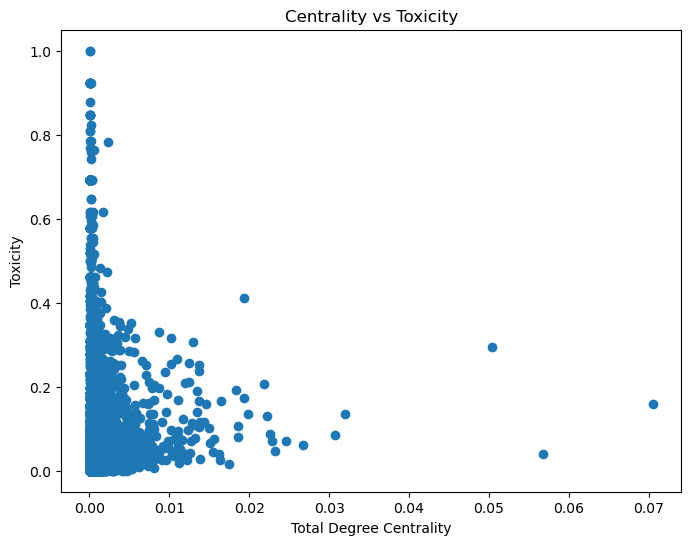

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(
    final_df["Total Degree Centrality"],
    final_df["normalized_toxicity"]
)

plt.xlabel("Total Degree Centrality")
plt.ylabel("Toxicity")

plt.title("Centrality vs Toxicity")

plt.show()

# Visualization — Correlation Heatmap

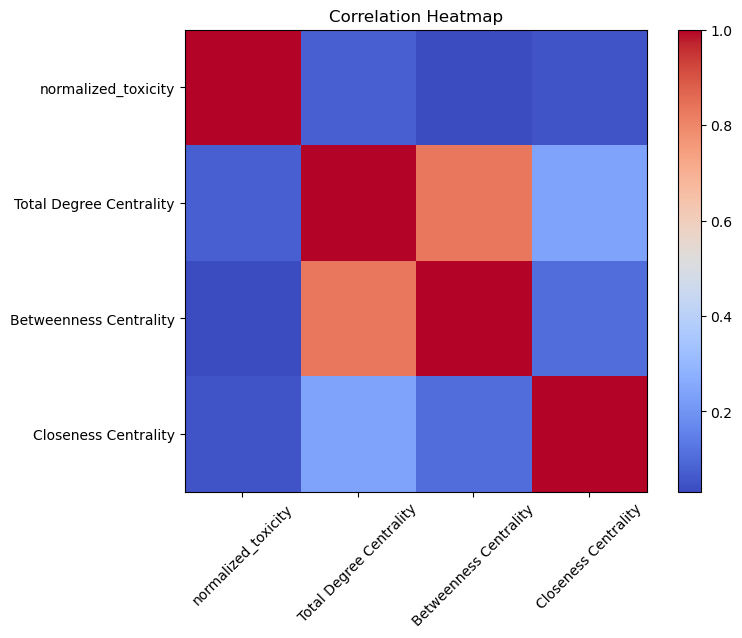

In [26]:
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.show()

# Save Outputs

In [29]:
final_df.to_csv(
    "../outputs/toxicity_scores.csv",
    index=False
)

In [30]:
# toxic_subreddits.csv
top_toxic.to_csv(
    "../outputs/toxic_subreddits.csv",
    index=False
)